In [1]:
#import libraraies - i imported this library to setup core analytical environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
#1. import database

In [3]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [4]:
# used connector to connect with mysql directly
import mysql.connector

In [5]:
conn  =  mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "priyanshu@123",
    database = "new_test")

In [6]:
cursor = conn.cursor()

In [7]:
#cursor.execute("create database new_test")

In [8]:
sql_query = "select * from db_customer"


In [9]:
# imported db_customer table for the overall data of the customers
tables = pd.read_sql(sql_query,conn)
tables.head()

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/759908615.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(sql_query,conn)


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None


In [10]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [1]:
#imported table db_subscription to find the subscription type of the customers
sql_query = "select * from db_subscription"

In [12]:
tables = pd.read_sql(sql_query,conn)
tables.head()

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/1858436618.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(sql_query,conn)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [13]:
# imported db_support table to find if the complaints escalated or not
sql_query = "select * from db_support"

In [14]:
tables = pd.read_sql(sql_query,conn)
#tables.head()
tables.tail()

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/2129141856.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(sql_query,conn)


,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01,N,30,None,None
5,0017-IUDMW,2024-04-10,Y,25,None,None
6,0019-EFAEP,2024-09-27,Y,30,None,None
7,0022-TCJCI,2024-09-13,Y,10,None,None
8,0022-TCJCI,2024-09-14,N,90,None,received refund


In [15]:
#data cleaning


In [16]:
df_customer = pd.read_sql("SELECT * FROM db_customer", conn)
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     object        
 1   name        21 non-null     object        
 2   country     18 non-null     object        
 3   state       21 non-null     object        
 4   gender      21 non-null     object        
 5   dob         21 non-null     datetime64[ns]
 6   interests   4 non-null      object        
 7   pincode     0 non-null      object        
dtypes: datetime64[ns](1), object(7)
memory usage: 1.4+ KB


/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/2736434920.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("SELECT * FROM db_customer", conn)


In [17]:
#a. rename col. name
#b. drop columns, interests and pincode
#c. fix missing values - country

In [18]:
#a. rename col. name
df_customer = pd.read_sql("SELECT * FROM db_customer", conn)
df_customer.rename(columns = {'name' : 'customer name'})

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/1771719320.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("SELECT * FROM db_customer", conn)


,customerid,customer name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29,None,None


In [19]:
# deleted interests and pincode because it was no use for further analysis
#b. drop columns, interests and pincode
df_customer = pd.read_sql("SELECT * FROM db_customer", conn)
#df_customer = df_customer.drop(df_customer.columns[-2:], axis=1)
df_customer.head()
df_customer.drop(columns = ['interests', 'pincode'], inplace = True)


/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/3957032309.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("SELECT * FROM db_customer", conn)


In [20]:
df_customer = pd.read_sql("SELECT * FROM db_customer", conn)
df_customer.drop(columns = ['interests', 'pincode'])

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/3670355473.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("SELECT * FROM db_customer", conn)


,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [21]:
df_customer = pd.read_sql("select * from db_customer", conn)
df_customer.drop(columns=['interests', 'pincode'], inplace=True)
df_customer.head()

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/55573496.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("select * from db_customer", conn)


,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [22]:
df_customer = pd.read_sql("SELECT * FROM db_customer", conn)
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   customerid  21 non-null     object        
 1   name        21 non-null     object        
 2   country     18 non-null     object        
 3   state       21 non-null     object        
 4   gender      21 non-null     object        
 5   dob         21 non-null     datetime64[ns]
 6   interests   4 non-null      object        
 7   pincode     0 non-null      object        
dtypes: datetime64[ns](1), object(7)
memory usage: 1.4+ KB


/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/2736434920.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("SELECT * FROM db_customer", conn)


In [23]:
#d. data standardisation - gender
df_customer = pd.read_sql("select* from db_customer", conn)
#df_customer['gender'].unique()
df_customer['gender'].replace({'Men' : 'Male'})

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/3328881038.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql("select* from db_customer", conn)


0       Male
1       Male
2     Female
3       Male
4     Female
5      Women
6     Female
7       Male
8      Women
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20     Women
Name: gender, dtype: object

In [24]:
#c. fix missing values - country


df_customer[df_customer['country'].isna()]

,customerid,name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01,None,None


In [25]:
df_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [26]:
#country and state - unique value pair

state_country_mapping = df_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_customer['country']=df_customer['country'].fillna(df_customer['state'].map(state_country_mapping))


In [27]:
df_customer[df_customer['country'].isna()]

,customerid,name,country,state,gender,dob,interests,pincode


In [28]:
df_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [29]:
df_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)
df_subscription.head()

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/1153044906.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [30]:
df_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [31]:
# changing data type of subscription_start_date, renewal_date,  cancellation_date to datetime
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_subscription[date_col] = df_subscription[date_col].apply(pd.to_datetime)
df_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [32]:
df_support = pd.read_sql('select * from db_support', conn)
df_support.head()

/var/folders/1v/4mqldr454ms6fc28c58gwqfw0000gn/T/ipykernel_10745/1464960994.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_support = pd.read_sql('select * from db_support', conn)


,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,None,service issue
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None,None
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None,None


In [33]:
df_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
 5   comment         4 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 564.0+ bytes


In [34]:
df_support.drop(columns = ['col_1'], inplace = True)

In [35]:
df_support.head()

,customerid,complaint_date,escalations,csat_score,comment
0,0003-MKNFE,2024-08-28,N,60,service issue
1,0003-MKNFE,2024-08-28,Y,10,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None
3,0013-MHZWF,2025-03-18,N,90,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None


In [36]:
#3 feature engineering in data analysis

In [37]:
#. created a new column using existing column - churn flag
df_subscription['churn_flag'] = np.where(df_subscription['cancellation_date'].notna(), 1, 0)

In [38]:
df_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [39]:
#first fixing the support table then duplicate then merging them
df=(df_subscription.merge(df_customer, on ='customerid', how= 'left').merge(df_support, on = 'customerid', how = 'left'))

In [40]:
df.shape

(23, 23)

In [41]:
df_subscription.shape

(21, 12)

In [42]:
df_support.shape

(9, 5)

In [43]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,comment
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,N,60.0,service issue
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,Y,10.0,demaned refund
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,movie,None,NaT,NaN,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,None,None,NaT,NaN,NaN,NaN


In [44]:
df_subscription['customerid'].nunique()

21

In [45]:
df_customer['customerid'].nunique()

21

In [46]:
df_support

,customerid,complaint_date,escalations,csat_score,comment
0,0003-MKNFE,2024-08-28,N,60,service issue
1,0003-MKNFE,2024-08-28,Y,10,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None
3,0013-MHZWF,2025-03-18,N,90,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None
5,0017-IUDMW,2024-04-10,Y,25,None
6,0019-EFAEP,2024-09-27,Y,30,None
7,0022-TCJCI,2024-09-13,Y,10,None
8,0022-TCJCI,2024-09-14,N,90,received refund


In [47]:
df.shape

(23, 23)

In [48]:
df_support['customerid'].size

9

In [49]:
df_support['complaint_count']=df_support.groupby('customerid')['customerid'].transform('count')

In [50]:
df_support=df_support.sort_values('complaint_date').drop_duplicates(subset=['customerid'], keep='last')

In [51]:
df_support['customerid'].nunique()

7

In [52]:
#merge df
df=(df_subscription.merge(df_customer, on ='customerid', how= 'left').merge(df_support, on = 'customerid', how = 'left'))

In [53]:
df.shape

(21, 24)

In [54]:
df.to_csv('exported_churn_data.csv', index = False)

In [55]:
from IPython.display import FileLink

FileLink('exported_churn_data.csv')

/Users/priyanshujha/exported_churn_data.csv

In [56]:
# data analysis

In [57]:
#1, finding churn rate

In [58]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'complaint_date', 'escalations', 'csat_score', 'comment',
       'complaint_count'],
      dtype='object')

In [59]:
df = df.drop(columns=['interests', 'pincode', 'comment'], errors='ignore')

In [60]:
from IPython.display import FileLink

FileLink('exported_churn_data.csv')

/Users/priyanshujha/exported_churn_data.csv

In [61]:
churn_rate=df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [62]:
#2. retention rate

In [63]:
retention_rate = 100-churn_rate
print("Retention Rate= ", round(retention_rate,2), "%")

Retention Rate=  71.43 %


In [64]:
#3. churn by plan type
df['churn_flag'] = pd.to_numeric(df['churn_flag'], errors='coerce')

churn_by_plan = (
    df.groupby('plan_type')['churn_flag']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='churn_rate_pct')
)

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [65]:
#4a. churn by state + sum(revenue) & count of users
#4b. churn by subscription type + sum(revenue) & count of users

In [66]:
churn_by_state = (
    df.groupby('state')
    .agg(
        user_count=('customerid', 'count'),
        churn_rate_pct=('churn_flag', lambda x: pd.to_numeric(x, errors='coerce').mean() * 100),
        sum_revenue=('monthly_charges', 'sum')
    )
    .round(2)
    .reset_index()
)

print(churn_by_state)

           state  user_count  churn_rate_pct  sum_revenue
0          Delhi           4           25.00        52.96
1      Karnataka           2          100.00        20.98
2      Kathmandu           2            0.00        20.98
3    Maharashtra           3            0.00        50.97
4      Meghalaya           3           66.67        42.97
5       Nagaland           1            0.00        22.99
6      Rajasthan           2            0.00        36.98
7      Telangana           2           50.00        30.98
8  Uttar Pradesh           2            0.00       115.98


In [67]:
# finding churn customers by subscription type
churn_by_sub_type = (
    df.groupby('subscription_type')
    .agg(
        user_count=('customerid', 'count'),
        churn_rate_pct=('churn_flag', lambda x: pd.to_numeric(x, errors='coerce').mean() * 100),
        sum_revenue=('monthly_charges', 'sum')
    )
    .round(2)
    .reset_index()
)

print(churn_by_sub_type)

  subscription_type  user_count  churn_rate_pct  sum_revenue
0           Organic           9            0.00       145.91
1              Paid           6           16.67       174.94
2          Refferal           6           83.33        74.94


In [68]:
#5. ARPU - average revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))
# used arpu to find how revenue a churning customer was generating for the company

ARPU =  18.85


In [69]:
#6. avg customer tenure
# count of days users has used our service : cancellation date else current date

today = pd.Timestamp.today()


# Convert date columns to datetime objects first
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], errors='coerce')
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], errors='coerce')

today = pd.Timestamp.today()

# Calculate tenure in days
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg tenure (Days) =", round(avg_tenure, 1))

Avg tenure (Days) = 1503.7


In [70]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [71]:
#7. revenue at risk - revenue last from churn users

revenue_at_risk=df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (rs 'k')= ", revenue_at_risk)

Revenue at Risk (rs 'k')=  73.94


In [72]:
# finding escalation rate to know if the problem was solved or not
#8. Escalation rate 

escalation_rate=(df['escalations']=='Y').mean()*100
print("Escalation Rate =",round(escalation_rate,2), "%")

Escalation Rate = 19.05 %


In [73]:
#9. avg complaint per user 
Avg_complaints= df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg complaints per user=", round(Avg_complaints, 2))

Avg complaints per user= 0.43


In [74]:
#10. correalation escalation vs churn
# 1. Directly convert 'escalations' string 'Y'/'N' to 1/0
escalations_binary = (df['escalations'].astype(str).str.strip().str.upper() == 'Y').astype(int)

# 2. Directly convert 'churn flag' to numeric integers
churn_binary = pd.to_numeric(df['churn_flag'], errors='coerce').fillna(0).astype(int)

# 3. Calculate correlation 
correlation = escalations_binary.corr(churn_binary)

print("Correlation between escalation vs churn is =", round(correlation, 2))

Correlation between escalation vs churn is = 0.77


In [75]:
#11 churn risk create a column using existing column 

conditions = [(df['churn_score']<50),
              (df['churn_score']>=50) &(df['churn_score']<70),
              (df['churn_score']>=70)                         
]

choices = ['low', 'medium', 'high']


df['churn-risk'] = np.select(conditions, choices, default ='unknown')           

In [76]:
df_visual = df.copy()

In [77]:
#4. visualisation using matplotlib

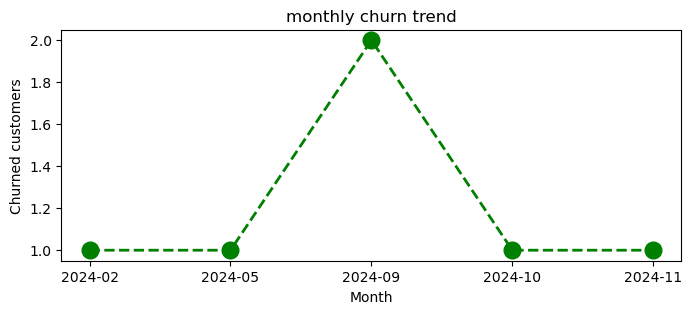

In [78]:
#4.1 monthly churn trend(time series KPI)

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))

plt.plot(churn_trend.index.astype('str'), churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('monthly churn trend')
plt.xlabel('Month')
plt.ylabel('Churned customers')
plt.show()

<BarContainer object of 3 artists>

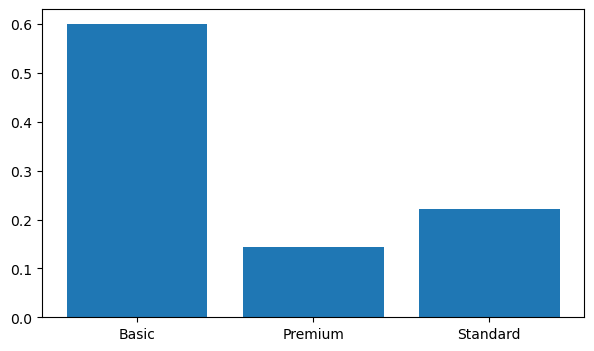

In [79]:
#4.2 churn by plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values)

<BarContainer object of 9 artists>

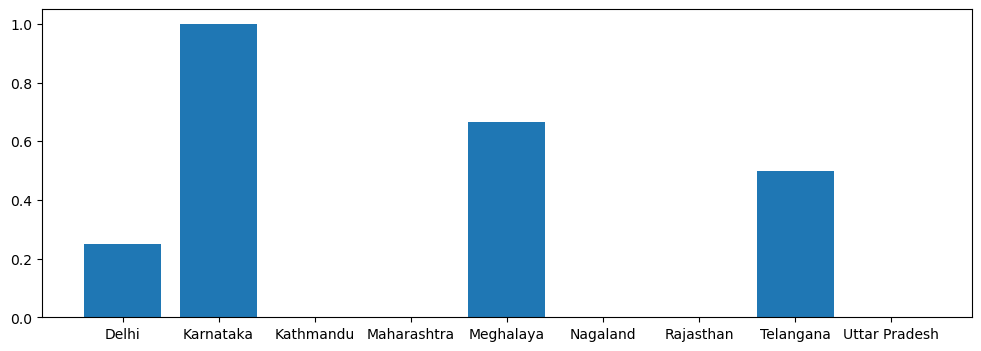

In [80]:
#4.3 churn by state

churn_plan = df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values)

In [81]:
#visualisation using seaborn
# heatmap (correlation matrix)

In [82]:
#encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn-risk', 'cancellation_month'],
      dtype='object')

In [83]:
df_visual = df_visual.rename(columns={'churn-risk': 'churn_risk'})

In [84]:
df_visual['escalations'] = df_visual['escalations'].notna().astype(int)

In [88]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [87]:
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()


caregorial_cols = ['plan_type', 'contract_type', 'churn_risk']
for col in caregorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [89]:
df_visual['escalations'] = (df_visual['escalations'] == 'Y').astype(int)

In [90]:
df_visual['escalations'] = df['escalations']

In [91]:
df_visual['escalations'] = (df_visual['escalations'] == 'Y').astype(int)

In [92]:
# Check which columns are exact duplicates
print("Are churn_flag and escalations identical?", (df_encoded['churn_flag'] == df_encoded['escalations']).all())
print("Are churn_flag and churn_risk identical?", (df_encoded['churn_flag'] == df_encoded['churn_risk']).all())

# Compare the actual original values side by side
df[['churn_flag', 'churn-risk', 'escalations']].head(10)

Are churn_flag and escalations identical? True
Are churn_flag and churn_risk identical? False


,churn_flag,churn-risk,escalations
0,0,low,NaN
1,1,high,Y
2,0,low,NaN
3,0,low,NaN
4,1,high,Y
5,0,low,N
6,1,high,N
7,0,low,NaN
8,0,low,NaN
9,0,low,NaN


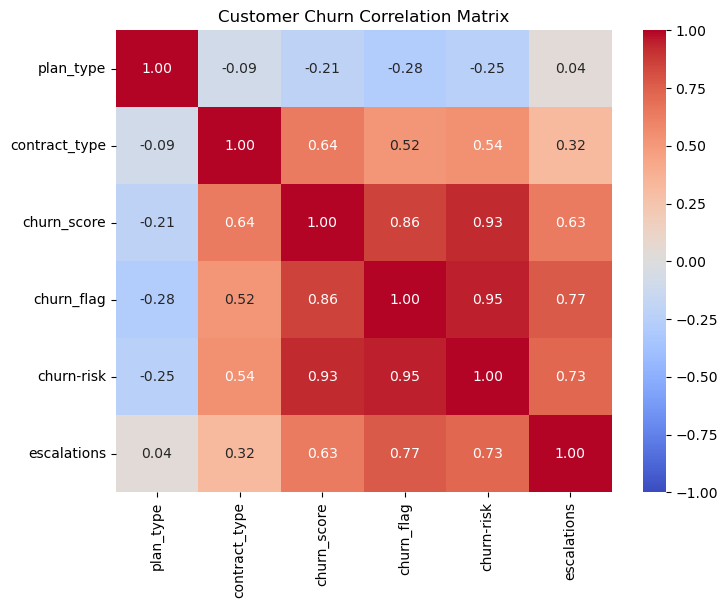

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Start fresh from raw dataframe 'df'
df_encoded = pd.DataFrame()

# 2. Encode plan_type & contract_type using category codes
df_encoded['plan_type'] = df['plan_type'].astype('category').cat.codes
df_encoded['contract_type'] = df['contract_type'].astype('category').cat.codes

# 3. Numeric columns (keep as is)
df_encoded['churn_score'] = df['churn_score']
df_encoded['churn_flag'] = df['churn_flag']

# 4. Explicit Ordinal Mapping for churn_risk (Low -> 0, Medium -> 1, High -> 2)
risk_map = {'low': 0, 'medium': 1, 'high': 2}
df_encoded['churn-risk'] = df['churn-risk'].str.lower().map(risk_map)

# 5. Binary Mapping for escalations ('Y' -> 1, anything else/NaN -> 0)
df_encoded['escalations'] = (df['escalations'] == 'Y').astype(int)

# 6. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Customer Churn Correlation Matrix")
plt.show()

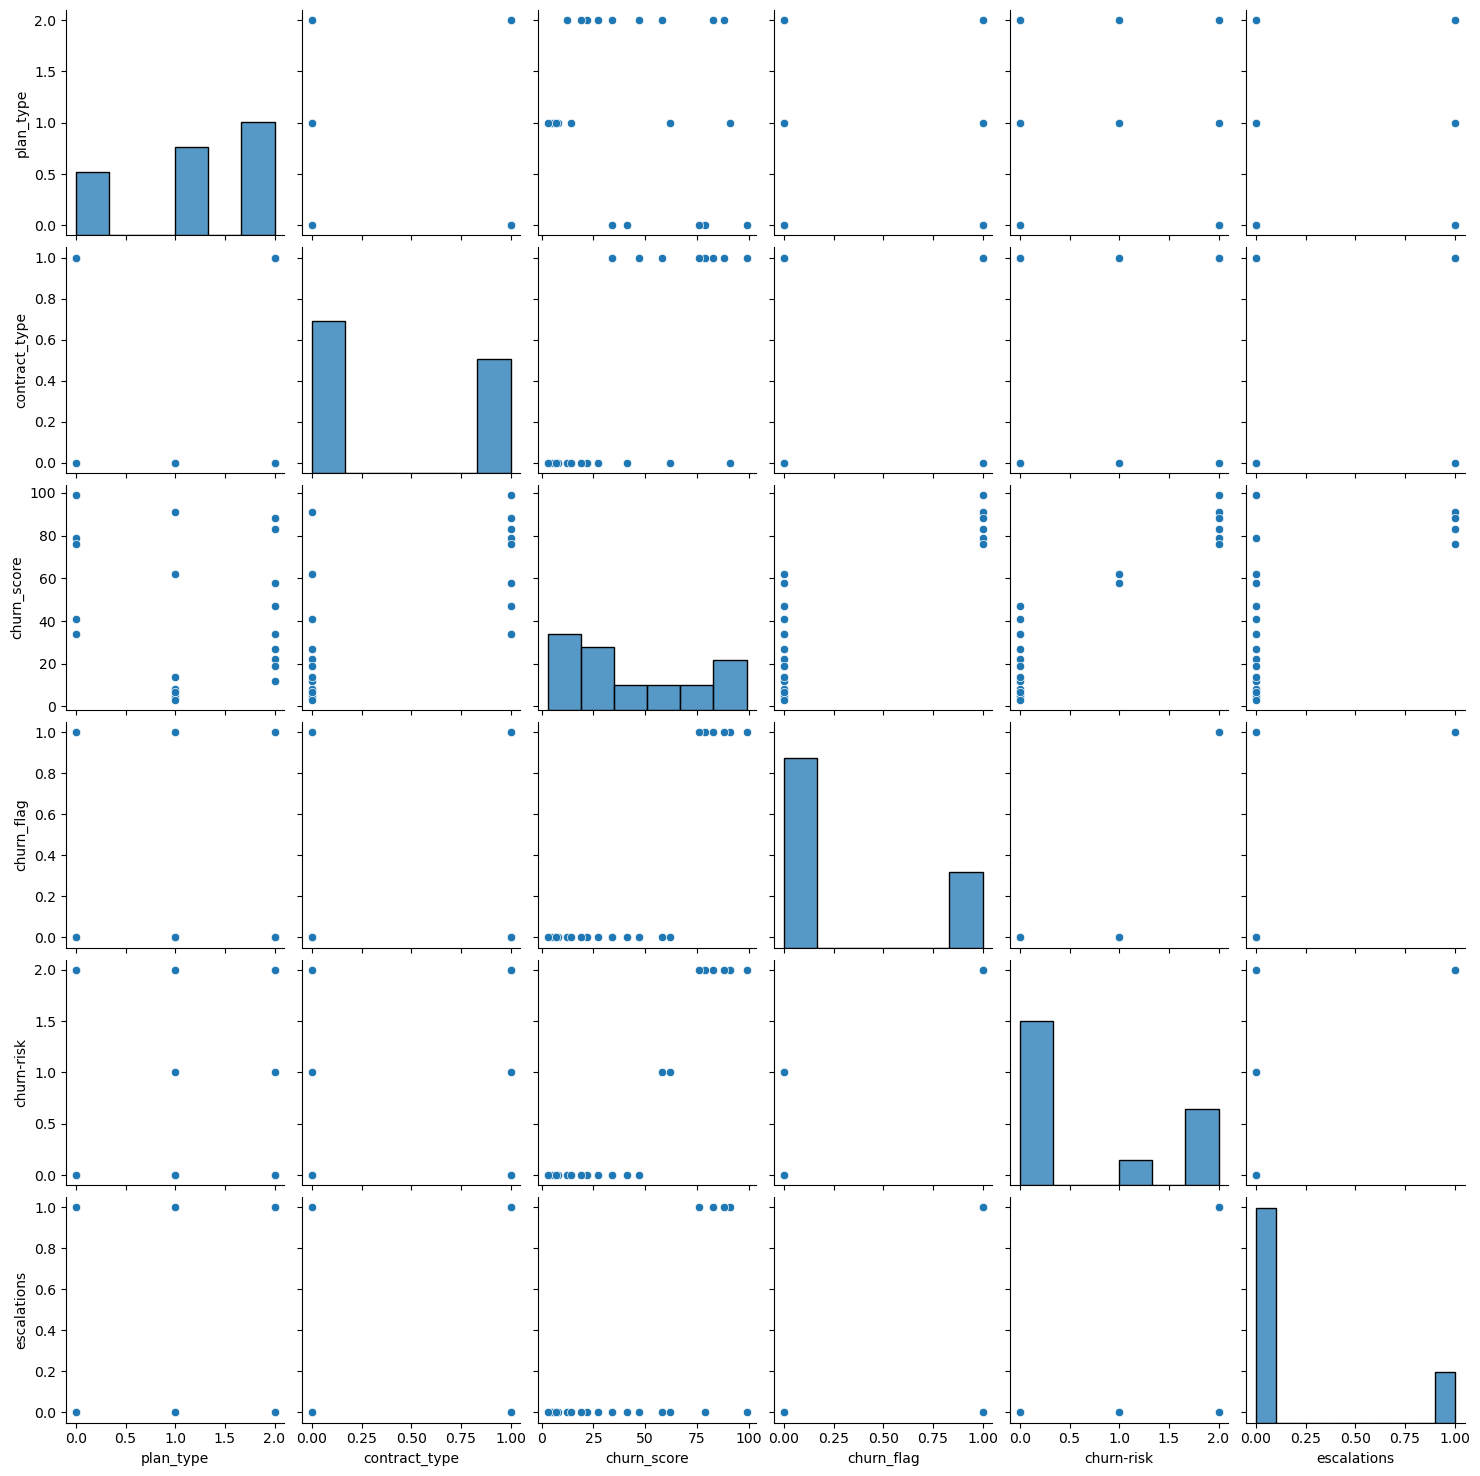

In [94]:
#pair plot - relationship ina data set
sns.pairplot(df_encoded)

In [95]:
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

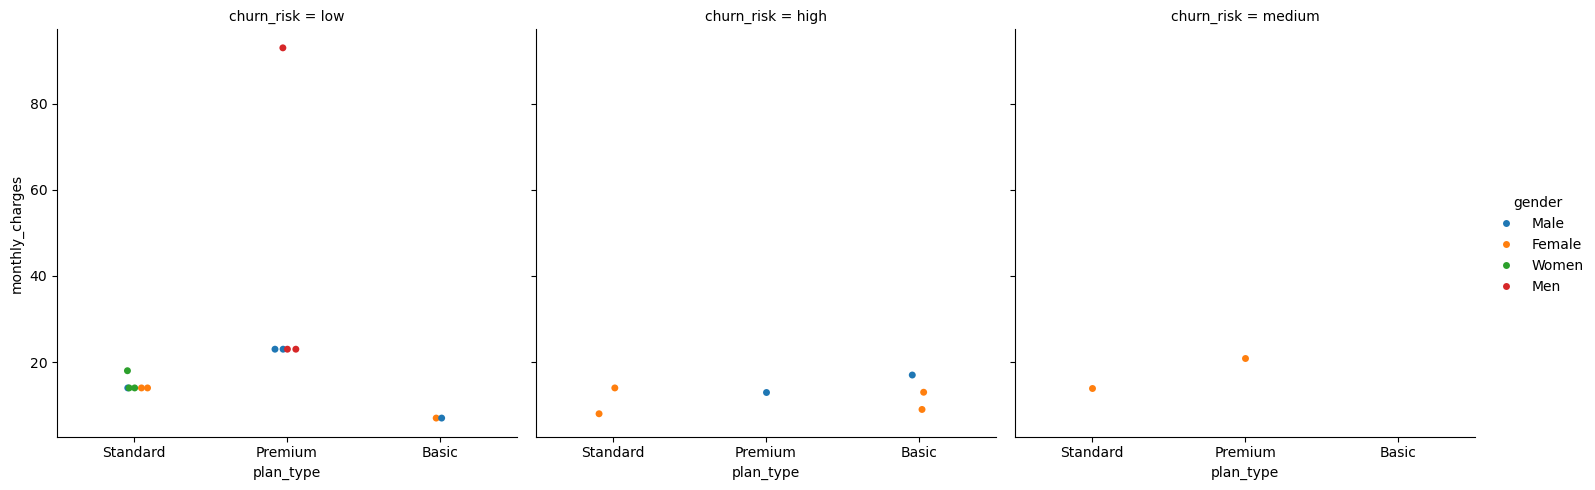

In [96]:
#catplot/facegrid plot - multiple-dim comparison
sns.catplot( data=df_visual,
    
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk',)

In [97]:
# pivot table

In [98]:
pd.pivot_table(df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean').reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [99]:
pd.pivot_table(df_visual,
    values=['monthly_charges','customerid', 'churn_flag'],
    index='plan_type',
    aggfunc={'monthly_charges':'sum',
             'customerid': 'nunique', 
             'churn_flag': 'mean'})

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
